# RetailPulse – Customer Churn Analysis & Prediction

## Objective

Identify customers who have become inactive and develop a
classification model to identify customers at higher risk of churn.

## Business Questions

1. How many customers are currently inactive?
2. Which customer segments contain the most at-risk customers?
3. Which customer behaviors are associated with inactivity?
4. Which high-value customers are at risk?
5. Can machine learning identify customers likely to become inactive?

## Approach

Customer Transactions
        ↓
Customer Features
        ↓
Define Churn
        ↓
Exploratory Churn Analysis
        ↓
Feature Engineering
        ↓
Classification Models
        ↓
Model Evaluation
        ↓
Business Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load customer transactions

In [2]:
CLEANED_DIR = Path("../data/cleaned")

customer = pd.read_csv(
    CLEANED_DIR / "retail_customer_analysis.csv"
)

rfm = pd.read_csv(
    CLEANED_DIR / "customer_rfm_segments.csv"
)

In [3]:
customer["InvoiceDate"] = pd.to_datetime(
    customer["InvoiceDate"],
    errors="coerce"
)

In [4]:
print("Customer transaction data:", customer.shape)
print("RFM data:", rfm.shape)

print("\nCustomer transaction columns:")
print(customer.columns.tolist())

print("\nRFM columns:")
print(rfm.columns.tolist())

Customer transaction data: (779425, 17)
RFM data: (5878, 10)

Customer transaction columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'TransactionType', 'Revenue', 'Year', 'Month', 'MonthName', 'Day', 'DayName', 'Week', 'Hour']

RFM columns:
['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment', 'Cluster']


## Understand the observation period

In [5]:
first_date = customer["InvoiceDate"].min()
last_date = customer["InvoiceDate"].max()

print("First transaction:", first_date)
print("Last transaction:", last_date)

First transaction: 2009-12-01 07:45:00
Last transaction: 2011-12-09 12:50:00


## Define churn threshold

In [6]:
CHURN_DAYS = 90

reference_date = (
    customer["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

churn_cutoff_date = (
    reference_date
    - pd.Timedelta(days=CHURN_DAYS)
)

print("Reference date:", reference_date)
print("Churn cutoff:", churn_cutoff_date)

Reference date: 2011-12-10 12:50:00
Churn cutoff: 2011-09-11 12:50:00


## Calculate customer-level behavior

In [7]:
customer_features = (
    customer
    .groupby("Customer_ID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        FirstPurchase=("InvoiceDate", "min"),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        AverageOrderValue=("Revenue", "mean")
    )
    .reset_index()
)

## Calculate Recency

In [8]:
customer_features["Recency"] = (
    reference_date
    - customer_features["LastPurchase"]
).dt.days

In [9]:
customer_features[
    [
        "Customer_ID",
        "LastPurchase",
        "Recency",
        "Frequency",
        "Monetary"
    ]
].head(20)

,Customer_ID,LastPurchase,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,326,12,77556.46
1,12347,2011-12-07 15:52:00,2,8,4921.53
2,12348,2011-09-25 13:13:00,75,5,2019.40
3,12349,2011-11-21 09:51:00,19,4,4428.69
4,12350,2011-02-02 16:01:00,310,1,334.40
5,12351,2010-11-29 15:23:00,375,1,300.93
6,12352,2011-11-03 14:37:00,36,10,2849.84
7,12353,2011-05-19 17:47:00,204,2,406.76
8,12354,2011-04-21 13:11:00,232,1,1079.40
9,12355,2011-05-09 13:49:00,214,2,947.61


## Customer lifetime

In [10]:
customer_features["CustomerLifetimeDays"] = (
    customer_features["LastPurchase"]
    - customer_features["FirstPurchase"]
).dt.days

## Create churn label

In [11]:
customer_features["Churn"] = np.where(
    customer_features["Recency"] > CHURN_DAYS,
    1,
    0
)

In [12]:
customer_features["Churn"].value_counts()

Churn
1    2989
0    2889
Name: count, dtype: int64

## Churn percentage

In [13]:
churn_summary = (
    customer_features["Churn"]
    .value_counts()
    .rename(index={
        0: "Active",
        1: "Churned"
    })
)

churn_summary

Churn
Churned    2989
Active     2889
Name: count, dtype: int64

In [14]:
churn_percentage = (
    customer_features["Churn"].mean()
    * 100
)

print(
    f"Inactive customer percentage: "
    f"{churn_percentage:.2f}%"
)

Inactive customer percentage: 50.85%


## Visualize churn distribution

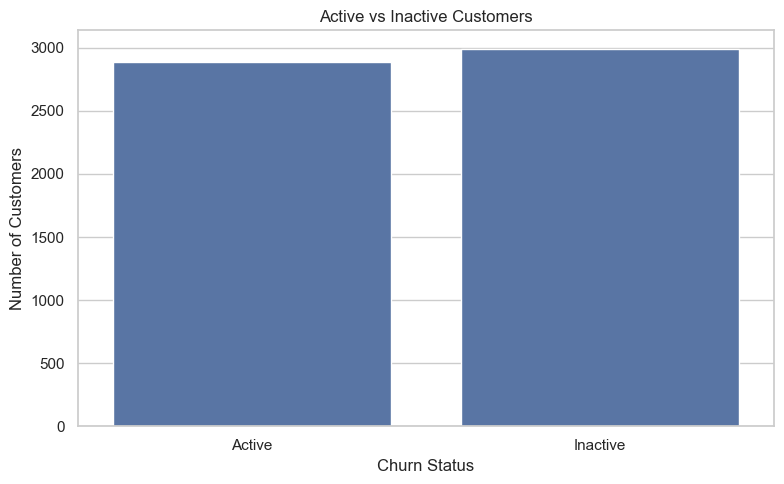

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_features,
    x="Churn"
)

plt.title("Active vs Inactive Customers")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1],
    ["Active", "Inactive"]
)

plt.tight_layout()
plt.show()

## Compare customer behavior

In [16]:
behavior_summary = (
    customer_features
    .groupby("Churn")
    [
        [
            "Recency",
            "Frequency",
            "Monetary",
            "TotalQuantity",
            "UniqueProducts",
            "AverageOrderValue"
        ]
    ]
    .mean()
    .round(2)
)

behavior_summary

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue
Churn,,,,,,
0,31.81,9.64,4840.23,2852.51,119.77,49.71
1,365.18,3.05,1134.62,760.48,45.48,46.94


## Churn by RFM segment

In [17]:
customer_features = customer_features.merge(
    rfm[
        [
            "Customer_ID",
            "Segment",
            "RFM_Score",
            "Cluster"
        ]
    ],
    on="Customer_ID",
    how="left"
)

In [18]:
churn_by_segment = (
    customer_features
    .groupby("Segment")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn", "sum"),
        Churn_Rate=("Churn", "mean"),
        Revenue=("Monetary", "sum")
    )
    .reset_index()
)

churn_by_segment["Churn_Rate"] *= 100

churn_by_segment.round(2)

,Segment,Customers,Churned,Churn_Rate,Revenue
0,At Risk,824,824,100.00,1589384.31
1,Champions,1297,0,0.00,11859591.50
2,High Value Customers,255,56,21.96,757157.86
3,Loyal Customers,701,283,40.37,1856667.02
4,New / Potential,417,0,0.00,176013.64
5,Other,2384,1826,76.59,1135989.93


## Churn rate by segment

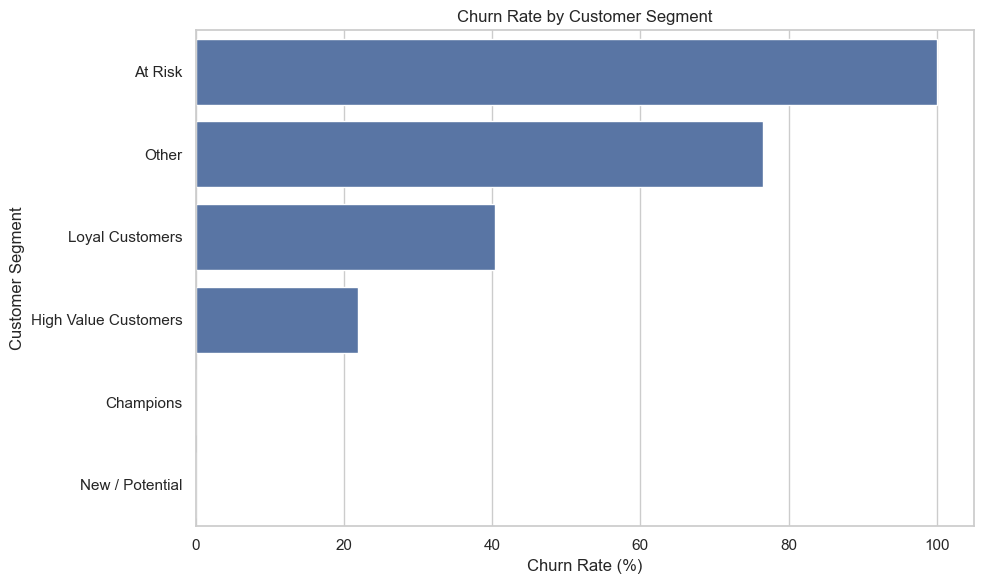

In [19]:
plt.figure(figsize=(10, 6))

plot_data = churn_by_segment.sort_values(
    "Churn_Rate",
    ascending=False
)

sns.barplot(
    data=plot_data,
    x="Churn_Rate",
    y="Segment"
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## High-value customers at risk

In [20]:
high_value_at_risk = customer_features[
    (customer_features["Churn"] == 1) &
    (customer_features["Monetary"] >= customer_features["Monetary"].quantile(0.75))
].copy()

In [21]:
print(
    "High-value inactive customers:",
    len(high_value_at_risk)
)

High-value inactive customers: 290


In [22]:
high_value_at_risk[
    [
        "Customer_ID",
        "Recency",
        "Frequency",
        "Monetary",
        "Segment"
    ]
].sort_values(
    "Monetary",
    ascending=False
).head(20)

,Customer_ID,Recency,Frequency,Monetary,Segment
0,12346,326,12,77556.46,At Risk
4364,16754,372,29,65500.07,At Risk
743,13093,276,55,54144.25,At Risk
5442,17850,372,155,51208.87,At Risk
3371,15749,235,3,44534.30,At Risk
2722,15098,182,3,39916.50,High Value Customers
1538,13902,632,5,34095.26,At Risk
1438,13802,139,19,26259.11,Loyal Customers
135,12482,576,29,23691.40,At Risk
1698,14063,438,9,22710.20,At Risk


## Feature selection

In [23]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AverageOrderValue",
    "CustomerLifetimeDays"
]

In [24]:
X = customer_features[features].copy()

y = customer_features["Churn"].copy()

In [25]:
model_features = [
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AverageOrderValue",
    "CustomerLifetimeDays"
]

## Prepare ML dataset

In [26]:
X = customer_features[
    model_features
].copy()

y = customer_features["Churn"].copy()

In [27]:
print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: (5878, 6)
Target: (5878,)

Target distribution:
Churn
1    2989
0    2889
Name: count, dtype: int64


## Check missing values

In [28]:
X.isnull().sum()

Frequency               0
Monetary                0
TotalQuantity           0
UniqueProducts          0
AverageOrderValue       0
CustomerLifetimeDays    0
dtype: int64

## Train/test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 4702
Testing records: 1176


## Scale features

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Logistic Regression

In [31]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

## Evaluate Logistic Regression

In [33]:
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.66      0.70       578
           1       0.70      0.77      0.74       598

    accuracy                           0.72      1176
   macro avg       0.72      0.72      0.72      1176
weighted avg       0.72      0.72      0.72      1176



In [34]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC AUC  :", round(logistic_auc, 4))

Accuracy : 0.7177
Precision: 0.7021
Recall   : 0.7726
F1 Score : 0.7357
ROC AUC  : 0.7908


## Random Forest

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

## Evaluate Random Forest

In [37]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC AUC  :", round(rf_auc, 4))

Accuracy : 0.7279
Precision: 0.7206
Recall   : 0.7592
F1 Score : 0.7394
ROC AUC  : 0.8028


## Compare models

In [38]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1": [
        logistic_f1,
        rf_f1
    ],
    "ROC_AUC": [
        logistic_auc,
        rf_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7177,0.7021,0.7726,0.7357,0.7908
1,Random Forest,0.7279,0.7206,0.7592,0.7394,0.8028


## Confusion matrix

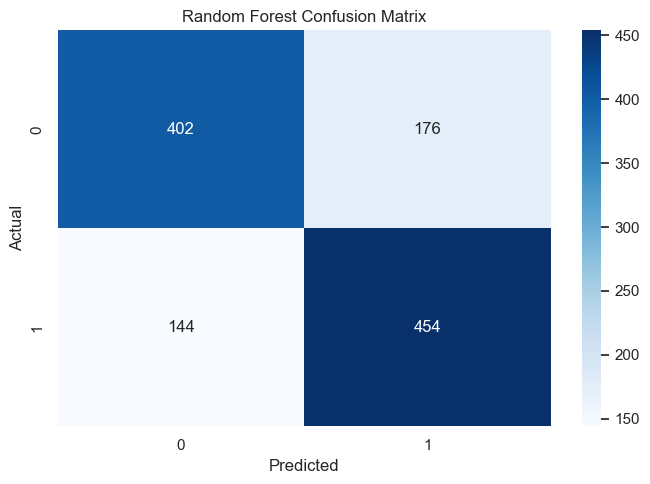

In [39]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Feature importance

In [40]:
feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,CustomerLifetimeDays,0.241856
2,TotalQuantity,0.184226
1,Monetary,0.183600
4,AverageOrderValue,0.154365
3,UniqueProducts,0.137367
0,Frequency,0.098586


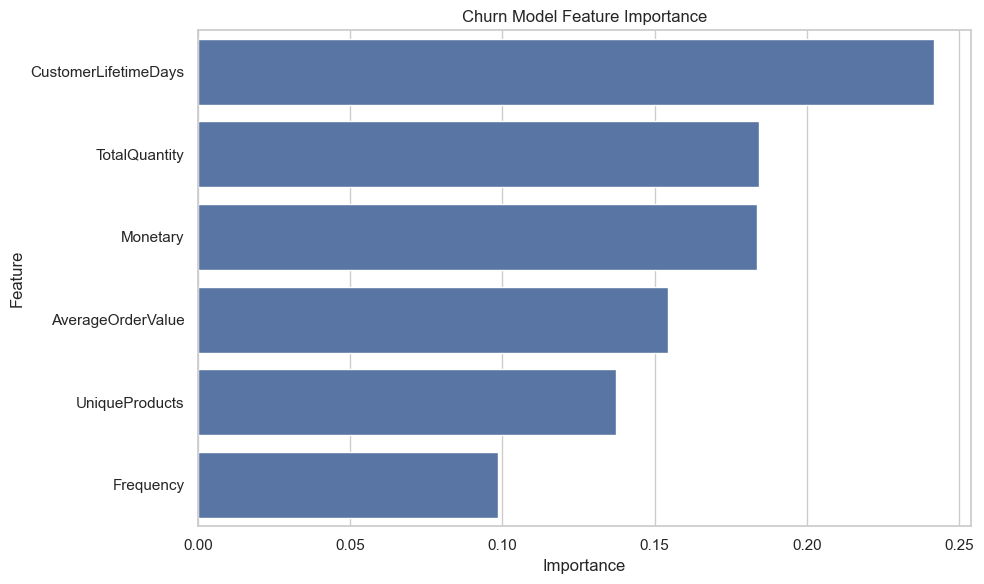

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Churn Model Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## ROC curve

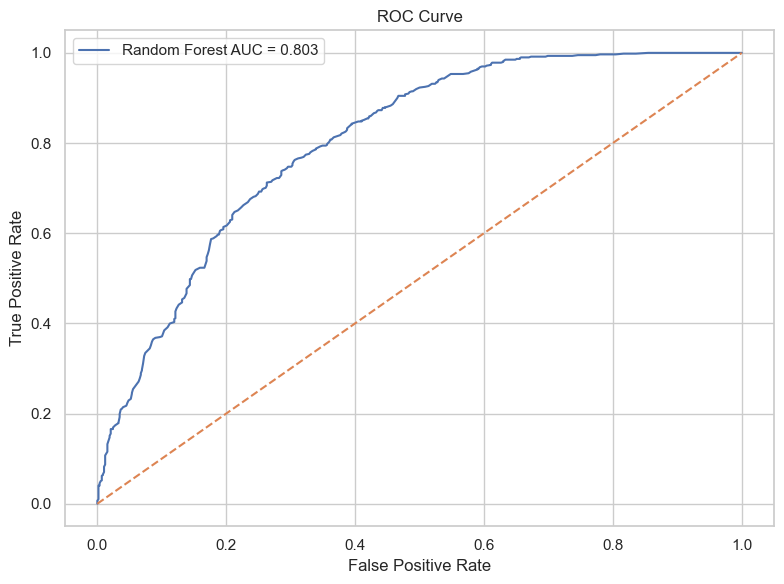

In [42]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()

## Create customer risk score

In [43]:
customer_features["ChurnProbability"] = rf_model.predict_proba(
    customer_features[model_features].fillna(0)
)[:, 1]

In [44]:
customer_features["RiskLevel"] = pd.cut(
    customer_features["ChurnProbability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

In [45]:
customer_features["RiskLevel"].value_counts()

RiskLevel
High Risk      2904
Low Risk       2494
Medium Risk     480
Name: count, dtype: int64

## High-risk customers

In [46]:
high_risk_customers = (
    customer_features[
        customer_features["RiskLevel"] == "High Risk"
    ]
    .sort_values(
        "ChurnProbability",
        ascending=False
    )
    .copy()
)

print("High-risk customers:", len(high_risk_customers))

High-risk customers: 2904


In [47]:
high_risk_customers[
    [
        "Customer_ID",
        "Recency",
        "Frequency",
        "Monetary",
        "Segment",
        "ChurnProbability",
        "RiskLevel"
    ]
].head(30)

,Customer_ID,Recency,Frequency,Monetary,Segment,ChurnProbability,RiskLevel
57,12404,682,1,63.24,Other,1.000000,High Risk
5703,18113,369,1,76.32,Other,1.000000,High Risk
2011,14380,682,1,48.96,Other,1.000000,High Risk
821,13172,400,1,69.60,Other,1.000000,High Risk
1725,14090,325,1,76.32,Other,1.000000,High Risk
834,13185,268,1,71.40,Other,1.000000,High Risk
3665,16047,682,1,107.14,Other,1.000000,High Risk
223,12570,682,1,77.52,Other,1.000000,High Risk
5658,18068,289,1,101.70,Other,1.000000,High Risk
2676,15052,319,1,207.73,Other,1.000000,High Risk


## Revenue at risk

In [48]:
revenue_at_risk = (
    high_risk_customers["Monetary"].sum()
)

print(
    f"Revenue associated with high-risk customers: "
    f"{revenue_at_risk:,.2f}"
)

Revenue associated with high-risk customers: 2,898,139.88


## Save churn dataset

In [49]:
customer_features.to_csv(
    CLEANED_DIR / "customer_churn_analysis.csv",
    index=False
)

model_results.to_csv(
    CLEANED_DIR / "churn_model_results.csv",
    index=False
)

feature_importance.to_csv(
    CLEANED_DIR / "churn_feature_importance.csv",
    index=False
)

print("Churn analysis outputs saved successfully.")

Churn analysis outputs saved successfully.


## Business conclusion

# Churn Analysis – Business Conclusions

## Customer Inactivity

The analysis defines churn as customer inactivity for more than 90 days
from the end of the observed transaction period.

This is a project-specific business definition because the original dataset
does not contain an explicit churn label.

## Customer Risk

Customers were analyzed based on purchase frequency, monetary value,
product diversity, order value, and customer lifetime.

## High-Value At-Risk Customers

Customers with high historical monetary value and high predicted churn
risk represent an important retention opportunity.

## Recommended Actions

1. Prioritize high-value customers with high churn probability.
2. Create personalized retention campaigns.
3. Offer incentives to customers showing declining engagement.
4. Monitor repeat-purchase behavior.
5. Track churn rate by RFM segment.
6. Monitor revenue associated with high-risk customers.

## Machine Learning

Logistic Regression and Random Forest were compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The model with the strongest business-relevant performance should be
selected for the final implementation.